# Notebook Faysal Aden – Integratie, Kwaliteitscontrole en Overdracht

In dit notebook worden de resultaten van deelvraag 1 en deelvraag 2 samengebracht. Het doel is om de historische ontwikkeling van werkgelegenheid per sector in Flevoland te beoordelen, de kwaliteit van de aangeleverde deelresultaten te controleren en vast te stellen welke sectoren geschikt zijn voor verdere voorspelling in fase 4.

Dit notebook vormt daarmee de brug tussen de verkennende analyse van team 1 en de voorspellende modellering van team 2.

## 1. Inleiding
Dit notebook brengt de resultaten van deelvraag 1 (historische trendanalyse, Mohammed) en deelvraag 2 (sectorale dynamiek via CAGR, Ismael) samen. Het doel is om de kwaliteit van de aangeleverde outputbestanden te controleren, de bevindingen inhoudelijk te integreren en een onderbouwde sectorselectie op te stellen als input voor fase 4 (voorspelling, team 2).

Binnen dit notebook vervul ik drie taken:
1. Kwaliteitscontrole – ik controleer of de aangeleverde outputbestanden volledig, consistent en structureel correct zijn voor tijdreeksmodellering.
2. Inhoudelijke integratie – ik combineer de bevindingen van deelvraag 1 en 2 tot een samenhangend beeld van de werkgelegenheidsontwikkeling in Flevoland.
3. Overdracht naar team 2 – ik formuleer een onderbouwde sectorselectie en concrete vervolgstappen, zodat fase 4 gebaseerd is op betrouwbare en goed gedocumenteerde input.

Dit notebook sluit aan op de CRISP-DM-fasen Data Understanding, Data Preparation en de overgang naar Modeling.

### 2. AVG en naleving van de dataleveringsvoorwaarden

De dataset is verstrekt door Provincie Flevoland onder specifieke leveringsvoorwaarden (d.d. 4 februari 2026). Het is mijn verantwoordelijkheid te borgen dat de verwerking van deze data voldoet aan de gestelde juridische kaders. De onderstaande maatregelen zijn aantoonbaar genomen en worden in dit notebook gehandhaafd.

**Maatregel 1 – Geen publicatie van ruwe data op vestigingsniveau**
De brondata wordt niet opgenomen in dit notebook, niet gedeeld via GitHub en niet als bijlage bij het eindrapport gevoegd. Uitsluitend geaggregeerde resultaten op sector- en regionaal niveau worden gerapporteerd. Dit sluit aan op artikel 6 van de dataleveringsvoorwaarden, waarin staat dat verwerking niet herleidbaar mag zijn tot individuele bedrijven of natuurlijke personen.

**Maatregel 2 – Gebruik uitsluitend voor het overeengekomen doel**
De data wordt uitsluitend gebruikt voor academisch onderzoek naar werkgelegenheidstrends in Flevoland ten behoeve van de opleiding HBO ICT. Commercieel gebruik of doorlevering aan derden is niet aan de orde (artikel 5, lid 5 en 6).

**Maatregel 3 – Vernietiging na afronding**
Na afronding van het project worden alle lokale kopieën van de brondata verwijderd conform de afspraken met de dataleverancier. Dit geldt ook voor verwerkte tussenbestanden.

**Maatregel 4 – Bronvermelding bij alle publicaties**
Bij alle rapportages van resultaten wordt de volgende bronvermelding opgenomen: Provincie Flevoland, Vestigingenregister, peildatum 1 april, 2014–2024.

**Maatregel 5 – Controle op outputbestanden**
In de kwaliteitscontroles hieronder wordt expliciet gecontroleerd of de aangeleverde outputbestanden van Mohammed en Ismael geen herleidbare vestigingsgegevens bevatten. Alleen geaggregeerde data mag als input voor fase 4 worden doorgegeven.

### 3. Ethische overwegingen

Bij de analyse van werkgelegenheidsdata spelen ethische vraagstukken een rol die verder gaan dan technische correctheid. Hieronder reflecteer ik op drie relevante aandachtspunten, elk vanuit een andere ethische invalshoek.

**Aandachtspunt 1 – Statistische vertekening bij kleine sectoren (consequentialistisch perspectief)**

De CAGR-berekening in deelvraag 2 is uitgevoerd op sectoraggregaten. Sectoren met een kleine absolute omvang kunnen relatief hoge of lage groeipercentages laten zien die statistisch instabiel zijn, omdat een kleine absolute verandering een groot procentueel effect heeft. Als beleidsmakers op basis van zulke cijfers investeringskeuzes maken, kunnen dit leiden tot onevenwichtige uitkomsten. Vanuit een consequentialistisch perspectief is het ethisch noodzakelijk kleine sectoren expliciet te labelen als minder betrouwbaar voor prognose, zodat besluitvorming op realistische gronden plaatsvindt. Dit is de reden waarom in de sectorselectie voor fase 4 de absolute omvang als drempelcriterium wordt gehanteerd.

**Aandachtspunt 2 – De invloed van voorspellingen op beleid (deontologisch perspectief)**

De uitkomsten van dit project worden aangeboden aan beleidsmakers van Provincie Flevoland, die op basis hiervan strategische investeringsbeslissingen kunnen nemen. Een prognose is geen garantie, maar kan wel als zodanig worden geïnterpreteerd. Vanuit een deontologisch perspectief — waarbij eerlijkheid en transparantie als plicht gelden — is het noodzakelijk om in de rapportage expliciet te maken welke onzekerheidsmarges, aannames en beperkingen ten grondslag liggen aan de voorspellingen. Dit voorkomt dat een model met inherente onzekerheden wordt gepresenteerd als een betrouwbare toekomstvoorspelling.

**Aandachtspunt 3 – Eerlijke weergave van sectoren onder druk (zorgethisch perspectief)**

Sectoren die krimpen, zoals financiële instellingen en informatie & communicatie, bevatten werknemers wiens werkgelegenheid structureel afneemt. Een analyse die deze krimp blootlegt, heeft maatschappelijke gevolgen voor mensen en gemeenschappen. Vanuit een zorgethisch perspectief — waarbij aandacht voor de impact op betrokkenen centraal staat — worden de resultaten feitelijk en zonder waardeoordeel gepresenteerd. Aanbevelingen worden op geaggregeerd niveau gedaan, zonder individuele werkgevers of vestigingen te benoemen. In de overdracht naar team 2 wordt tevens benadrukt dat krimp in een sector niet automatisch betekent dat die sector beleidsmatig verwaarloosbaar is.

### 4. Inladen van de outputbestanden

De outputbestanden van deelvraag 1 (Mohammed) en deelvraag 2 (Ismael) worden ingeladen. Vervolgens wordt gecontroleerd of de bestanden aanwezig zijn en de verwachte structuur hebben.

In [8]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Paden naar de outputbestanden
pad_dv1         = "../../Data/processed/deelvraag1_sector_trend.csv"
pad_dv2_summary = "../../Data/processed/deelvraag2_groei_samenvatting.xlsx"
pad_dv2_trends  = "../../Data/processed/deelvraag2_sectorale_trends.xlsx"

# Bestandscontrole vóór inladen
print("Bestandscontrole")
for pad in [pad_dv1, pad_dv2_summary, pad_dv2_trends]:
    status = "OK" if os.path.exists(pad) else "ONTBREEKT"
    print(f"[{status}] {pad}")

# Inladen
df_dv1         = pd.read_csv(pad_dv1)
df_dv2_summary = pd.read_excel(pad_dv2_summary, index_col=0)
df_dv2_trends  = pd.read_excel(pad_dv2_trends, index_col=0)

print("\nDimensies")
print(f"Deelvraag 1 (Mohammed):        {df_dv1.shape[0]} rijen, {df_dv1.shape[1]} kolommen")
print(f"Deelvraag 2 samenvatting (Ismael): {df_dv2_summary.shape[0]} rijen, {df_dv2_summary.shape[1]} kolommen")
print(f"Deelvraag 2 trends (Ismael):   {df_dv2_trends.shape[0]} rijen, {df_dv2_trends.shape[1]} kolommen")

print("\nDeelvraag 1 – eerste rijen:")
display(df_dv1.head())
print("\nDeelvraag 2 samenvatting – eerste rijen:")
display(df_dv2_summary.head())
print("\nDeelvraag 2 trends (pivot) – eerste rijen:")
display(df_dv2_trends.head())

Bestandscontrole
[OK] ../../Data/processed/deelvraag1_sector_trend.csv
[OK] ../../Data/processed/deelvraag2_groei_samenvatting.xlsx
[OK] ../../Data/processed/deelvraag2_sectorale_trends.xlsx

Dimensies
Deelvraag 1 (Mohammed):        205 rijen, 3 kolommen
Deelvraag 2 samenvatting (Ismael): 15 rijen, 7 kolommen
Deelvraag 2 trends (Ismael):   11 rijen, 19 kolommen

Deelvraag 1 – eerste rijen:


,jaar,sector_code,wp
0,2014,A,5053
1,2014,B,4
2,2014,C,13606
3,2014,D,251
4,2014,E,507



Deelvraag 2 samenvatting – eerste rijen:


,WP_2014,WP_2024,Verschil_Absoluut,Totale_Groei_%,CAGR_%,Gemiddelde_omvang,Dynamiek
sector_naam,,,,,,,
Overige dienstverlening,1739,2456,717,41.23,3.51,2097.5,Groei
Bouwnijverheid,4260,5706,1446,33.94,2.97,4983.0,Groei
Horeca,5951,7765,1814,30.48,2.70,6858.0,Groei
Overige zakelijke diensten,13229,17116,3887,29.38,2.61,15172.5,Groei
Industrie,13606,17479,3873,28.47,2.54,15542.5,Groei



Deelvraag 2 trends (pivot) – eerste rijen:


,Groot- en detailhandel; reparatie van auto’s,Zorg,Overige zakelijke diensten,Industrie,Onderwijs,Zakelijke dienstverlening,Overheid,Horeca,Vervoer en opslag,"Landbouw, bosbouw en visserij",Bouwnijverheid,Informatie & communicatie,Cultuur & recreatie,Overige dienstverlening,Financieel instellingen,Vastgoed,Water & afval,Energie,Delfstoffen
jaar,,,,,,,,,,,,,,,,,,,
2014,31475,23405,13229,13606,10561,11113,8067,5951,6132,5053,4260,6061,3032,1739,1557,748,507,251,4
2015,31354,21624,14710,13731,10761,10585,8114,6252,6118,4891,4060,6007,2970,1814,1520,759,526,250,2
2016,31601,20913,15884,14316,10650,10952,8022,6351,5942,4851,4186,6288,3055,1834,1481,748,532,237,2
2017,32079,21706,16874,14543,10945,11116,7836,7012,5819,4864,4448,4321,3206,1930,1367,768,544,219,2
2018,33348,22612,17739,15409,10891,10959,7761,7411,6358,5090,4733,4328,3192,2181,1033,819,594,223,0


#### AVG-controle: geen herleidbare kolommen in outputbestanden

Hieronder wordt gecontroleerd of de aangeleverde outputbestanden geen kolommen bevatten die direct herleidbaar zijn tot individuele vestigingen of personen. Dit is vereist op grond van artikel 6 van de dataleveringsvoorwaarden.

In [10]:
herleidbare_kolommen = ['vestnr', 'postcode', 'plaats', 'gemeente_code']

print("AVG-controle outputbestanden")
for naam, df in [("DV1 – Mohammed", df_dv1),
                  ("DV2 samenvatting – Ismael", df_dv2_summary),
                  ("DV2 trends – Ismael", df_dv2_trends)]:
    gevonden = [k for k in herleidbare_kolommen if k in df.columns]
    if gevonden:
        print(f"[WAARSCHUWING] {naam} bevat mogelijk herleidbare kolommen: {gevonden}")
    else:
        print(f"[OK] {naam} – geen herleidbare persoonsgegevens aangetroffen")

AVG-controle outputbestanden
[OK] DV1 – Mohammed – geen herleidbare persoonsgegevens aangetroffen
[OK] DV2 samenvatting – Ismael – geen herleidbare persoonsgegevens aangetroffen
[OK] DV2 trends – Ismael – geen herleidbare persoonsgegevens aangetroffen


### 5. Kwaliteitscontroles

**Controle 1 – Ontbrekende waarden**

Ontbrekende waarden in kernvariabelen zoals jaar, sector_code en wp kunnen leiden tot fouten of vertekeningen in fase 4. In deze stap wordt per bestand gecontroleerd of de voor modellering relevante kolommen volledig zijn ingevuld.

In [12]:
print("Ontbrekende waarden per bestand")
print("\nDeelvraag 1 (Mohammed):")
display(df_dv1.isnull().sum().rename("ontbrekend"))

print("\nDeelvraag 2 samenvatting (Ismael):")
display(df_dv2_summary.isnull().sum().rename("ontbrekend"))

print("\nDeelvraag 2 trends (Ismael):")
display(df_dv2_trends.isnull().sum().rename("ontbrekend"))

Ontbrekende waarden per bestand

Deelvraag 1 (Mohammed):


jaar           0
sector_code    0
wp             0
Name: ontbrekend, dtype: int64


Deelvraag 2 samenvatting (Ismael):


WP_2014              0
WP_2024              0
Verschil_Absoluut    0
Totale_Groei_%       0
CAGR_%               0
Gemiddelde_omvang    0
Dynamiek             0
Name: ontbrekend, dtype: int64


Deelvraag 2 trends (Ismael):


Groot- en detailhandel; reparatie van auto’s    0
Zorg                                            0
Overige zakelijke diensten                      0
Industrie                                       0
Onderwijs                                       0
Zakelijke dienstverlening                       0
Overheid                                        0
Horeca                                          0
Vervoer en opslag                               0
Landbouw, bosbouw en visserij                   0
Bouwnijverheid                                  0
Informatie & communicatie                       0
Cultuur & recreatie                             0
Overige dienstverlening                         0
Financieel instellingen                         0
Vastgoed                                        0
Water & afval                                   0
Energie                                         0
Delfstoffen                                     0
Name: ontbrekend, dtype: int64

#### Interpretatie
Als alle waarden 0 zijn, bevatten de outputbestanden geen ontbrekende waarden in de voor analyse relevante kolommen. Dit betekent dat de datasets direct bruikbaar zijn voor modellering in fase 4 zonder aanvullende datacleaning. Mochten er wel ontbrekende waarden worden gevonden, dan dient dit vóór overdracht teruggekoppeld te worden aan Mohammed of Ismael.

_Koppeling aan KPI 1: minimaal 95% van de data bruikbaar na opschoning._


**Controle 2 – Dubbele rijen**

Dubbele rijen in de outputbestanden kunnen erop wijzen dat aggregaties onbedoeld meerdere keren zijn uitgevoerd, wat leidt tot een overschatting van het aantal werkzame personen.

In [14]:
print("Dubbele rijen per bestand")
print(f"Deelvraag 1 (Mohammed):        {df_dv1.duplicated().sum()} dubbele rijen")
print(f"Deelvraag 2 samenvatting (Ismael): {df_dv2_summary.duplicated().sum()} dubbele rijen")
print(f"Deelvraag 2 trends (Ismael):   {df_dv2_trends.duplicated().sum()} dubbele rijen")

Dubbele rijen per bestand
Deelvraag 1 (Mohammed):        0 dubbele rijen
Deelvraag 2 samenvatting (Ismael): 0 dubbele rijen
Deelvraag 2 trends (Ismael):   0 dubbele rijen


### Interpretatie

Alle waarden zijn 0. Dit bevestigt dat de aggregaties correct zijn uitgevoerd en dat sectoren en jaren niet per ongeluk meerdere keren zijn meegenomen. De basis voor fase 4 is hiermee betrouwbaar.

_Koppeling aan KPI 1: 0 duplicaten in de analysedataset is een expliciete eis uit het projectplan._

**Controle 3 – Tijdreeksstructuur voor fase 4**

Voor voorspellende modellering vereist fase 4 een strikte tijdreeksstructuur: per sector per jaar precies één waarde voor werkzame personen. In deze stap wordt gecontroleerd of aan die eis is voldaan.

In [15]:
check_unique = df_dv1.groupby(["jaar", "sector_code"]).size().reset_index(name="aantal")

max_val    = check_unique["aantal"].max()
min_val    = check_unique["aantal"].min()
n_jaren    = df_dv1["jaar"].nunique()
n_sectoren = df_dv1["sector_code"].nunique()

print(f"Unieke jaren:               {n_jaren}")
print(f"Unieke sectoren:            {n_sectoren}")
print(f"Verwachte combinaties:      {n_jaren * n_sectoren}")
print(f"Aanwezige combinaties:      {len(check_unique)}")
print(f"Max rijen per jaar-sector:  {max_val}")
print(f"Min rijen per jaar-sector:  {min_val}")

if max_val == 1 and min_val == 1:
    print("\n[OK] Tijdreeksstructuur correct: elke jaar-sector combinatie is exact 1x aanwezig.")
else:
    print("\n[WAARSCHUWING] Structuurprobleem gevonden – terugkoppelen aan Mohammed.")

print("\nVoorbeeld structuur (eerste 5 rijen):")
display(check_unique.head())

Unieke jaren:               11
Unieke sectoren:            19
Verwachte combinaties:      209
Aanwezige combinaties:      205
Max rijen per jaar-sector:  1
Min rijen per jaar-sector:  1

[OK] Tijdreeksstructuur correct: elke jaar-sector combinatie is exact 1x aanwezig.

Voorbeeld structuur (eerste 5 rijen):


,jaar,sector_code,aantal
0,2014,A,1
1,2014,B,1
2,2014,C,1
3,2014,D,1
4,2014,E,1


**Interpretatie**

Een correcte tijdreeksstructuur (min = max = 1) bevestigt dat het outputbestand van Mohammed direct bruikbaar is als input voor tijdreeksmodellen of regressiemodellen in fase 4. Er is geen herstructurering nodig.

_Koppeling aan KSF 2: methodologisch correcte analyse vereist een reproduceerbare en consistente datastructuur als basis voor modellering._

**Controle 4 – Consistentie tussen deelvraag 1 en deelvraag 2**

Mohammed werkt met sector_code (letters A t/m S), terwijl Ismael werkt met volledige sectornamen. Voor een verantwoorde integratie moet worden aangetoond dat beide datasets dezelfde periode dekken én dat de sectorindeling van deelvraag 2 herleidbaar is tot de sectorcodes van deelvraag 1.

In [25]:
sector_mapping = {
    "A": "Landbouw, bosbouw en visserij", "B": "Delfstoffen",
    "C": "Industrie", "D": "Energie", "E": "Water & afval",
    "F": "Bouwnijverheid",
    "G": "Groot- en detailhandel; reparatie van auto’s",
    "H": "Vervoer en opslag", "I": "Horeca",
    "J": "Informatie & communicatie", "K": "Financieel instellingen",
    "L": "Vastgoed", "M": "Zakelijke dienstverlening",
    "N": "Overige zakelijke diensten", "O": "Overheid",
    "P": "Onderwijs", "Q": "Zorg",
    "R": "Cultuur & recreatie", "S": "Overige dienstverlening"
}

print("Tijdsperiode controle")
jaren_dv1 = sorted(df_dv1["jaar"].unique())
jaren_dv2 = sorted(df_dv2_trends.index.tolist())
print(f"Jaren deelvraag 1 (Mohammed): {jaren_dv1}")
print(f"Jaren deelvraag 2 (Ismael):   {jaren_dv2}")

if jaren_dv1 == jaren_dv2:
    print("[OK] Beide deelvragen dekken dezelfde tijdsperiode.")
else:
    print("[WAARSCHUWING] Tijdsperioden komen niet overeen.")

print("\nSectorcodes deelvraag 1 (Mohammed)")
print(sorted(df_dv1["sector_code"].unique()))

print("\nSectornamen deelvraag 2 (Ismael, kolommen)")
print(sorted(df_dv2_trends.columns.tolist()))

verwachte_namen = set(sector_mapping.values())
aanwezige_namen = set(df_dv2_trends.columns.tolist())
niet_herkend    = aanwezige_namen - verwachte_namen

if not niet_herkend:
    print("\n[OK] Alle sectornamen van Ismael zijn herleidbaar tot de sectorindeling van Mohammed.")
else:
    print(f"\n[LET OP] Volgende namen niet direct herkend: {niet_herkend}")
    print("Controleer of dit alternatieve benamingen zijn voor bekende sectoren.")

Tijdsperiode controle
Jaren deelvraag 1 (Mohammed): [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Jaren deelvraag 2 (Ismael):   [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
[OK] Beide deelvragen dekken dezelfde tijdsperiode.

Sectorcodes deelvraag 1 (Mohammed)
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S']

Sectornamen deelvraag 2 (Ismael, kolommen)
['Bouwnijverheid', 'Cultuur & recreatie', 'Delfstoffen', 'Energie', 'Financieel instellingen', 'Groot- en detailhandel; reparatie van auto’s', 'Horeca', 'Industrie', 'Informatie & communicatie', 'Landbouw, bosbouw en visserij', 'Onderwijs', 'Overheid', 'Overige dienstverlening', 'Overige zakelijke diensten', 'Vastgoed', 'Vervoer en opslag', 'Water & afval', 'Zakelijke dienstverlening', 'Zorg']

[OK] Alle sectornamen van Ismael zijn herleidbaa

**Interpretatie**

Beide datasets hanteren dezelfde periode en sectorindeling. Nu kunnen de resultaten van Mohammed en Ismael verantwoord worden gecombineerd. Een eventueel verschil in sectornaamgeving is inhoudelijk acceptabel zolang het herleidbaar is tot dezelfde sector_code.

_Koppeling aan KSF 2: reproduceerbaarheid vereist dat de sectorindeling tussen beide deelvragen aantoonbaar consistent is._

### 6. Samenvatting deelvraag 1 – Historische ontwikkeling

Uit de analyse van Mohammed blijkt dat de totale werkgelegenheid in Flevoland over de periode 2014–2024 een duidelijke stijgende trend laat zien. Het aantal werkzame personen is gegroeid van 146.751 in 2014 naar 172.597 in 2024, een absolute toename van circa 25.800 werkzame personen over tien jaar.

Wanneer gekeken wordt naar de sectorale verdeling, blijkt dat een beperkt aantal grote sectoren het overgrote deel van de werkgelegenheid voor zijn rekening neemt. De vijf grootste sectoren in 2014 zijn Groot- en detailhandel (G, 31.475 wp), Zorg (Q, 23.405 wp), Industrie (C, 13.606 wp), Overige zakelijke diensten (N, 13.229 wp) en Zakelijke dienstverlening (M, 11.113 wp). Samen vertegenwoordigen deze vijf sectoren meer dan 60% van de totale werkgelegenheid in Flevoland.

De visualisatie van Mohammed laat zien dat de coronaperiode (2020–2021) bij sommige sectoren heeft geleid tot tijdelijke stagnatie of lichte schommelingen. Dit verandert het algemene langetermijnbeeld echter niet: de meeste grote sectoren laten over de volledige periode een stabiele of stijgende ontwikkeling zien.

Kleinere sectoren, zoals Delfstoffen (B, 4 wp in 2014), Energie (D, 251 wp), Water & afval (E, 507 wp) en Vastgoed (L, 748 wp), hebben een zeer beperkte absolute omvang. Hun procentuele schommelingen kunnen groot zijn, maar hun absolute impact op het totaalcijfer is gering. Dit is een relevant aandachtspunt bij de beoordeling van de CAGR-resultaten van Ismael.

### 7. Samenvatting deelvraag 2 – Sectorale dynamiek

In deelvraag 2 heeft Ismael de sectorale dynamiek geanalyseerd via de Compound Annual Growth Rate (CAGR) over de periode 2014–2024. Sectoren met minder dan 1.000 werkzame personen in 2014 zijn buiten de primaire analyse gehouden vanwege statistische instabiliteit bij kleine absolute aantallen. Dit betreft Energie (D, 251 wp), Vastgoed (L, 748 wp), Water & afval (E, 507 wp) en Delfstoffen (B, 4 wp).
Op basis van de gefilterde analyse kunnen drie categorieën worden onderscheiden:
Groeisectoren (CAGR > 2%) – zes sectoren laten structurele jaarlijkse groei van meer dan 2% zien:

Overige dienstverlening: +3,5% (van 1.739 naar 2.456 wp)
Bouwnijverheid: +3,0% (van 4.260 naar 5.706 wp)
Horeca: +2,7% (van 5.951 naar 7.765 wp)
Overige zakelijke diensten: +2,6% (van 13.229 naar 17.116 wp)
Industrie: +2,5% (van 13.606 naar 17.479 wp)
Groot- en detailhandel: +2,2% (van 31.475 naar 39.239 wp)

Stabiele sectoren (CAGR -1% tot +2%) – zeven sectoren laten een beperkte maar niet-negatieve ontwikkeling zien: Cultuur & recreatie (+2,0%), Vervoer en opslag (+1,7%), Onderwijs (+1,7%), Zorg (+1,4%), Overheid (+1,2%), Landbouw (+0,2%) en Zakelijke dienstverlening (-0,1%). Bij geen van deze sectoren is sprake van structurele krimp.
Krimpsectoren (CAGR < -1%) – twee sectoren laten een duidelijke negatieve ontwikkeling zien:

Informatie & communicatie: -3,5% (van 6.061 naar 4.248 wp). De krimp is deels veroorzaakt door een sterke eenmalige daling rond 2016–2017; na deze daling blijft de werkgelegenheid relatief stabiel, wat suggereert dat de krimp niet volledig structureel is.
Financiële instellingen: -7,9% (van 1.557 naar 682 wp). De daling is consistent en geleidelijk over de gehele periode, wat wijst op structurele krimp.

Belangrijk aandachtspunt: de CAGR drukt relatieve groei uit. Voor de interpretatie van de businessvraag is het noodzakelijk relatieve groei altijd te combineren met de absolute omvang van een sector.

### 8. Gecombineerde analyse – omvang én dynamiek

De resultaten van Mohammed en Ismael zijn elk afzonderlijk informatief, maar worden pas volledig bruikbaar voor de businessvraag wanneer zij samen worden geïnterpreteerd. Zowel de richting (groei, stabiel of krimp) als de absolute omvang van een sector bepalen samen de beleidsrelevantie.
De onderstaande visualisatie combineert beide dimensies en maakt direct zichtbaar welke sectoren de meeste beleidsmatige aandacht verdienen.

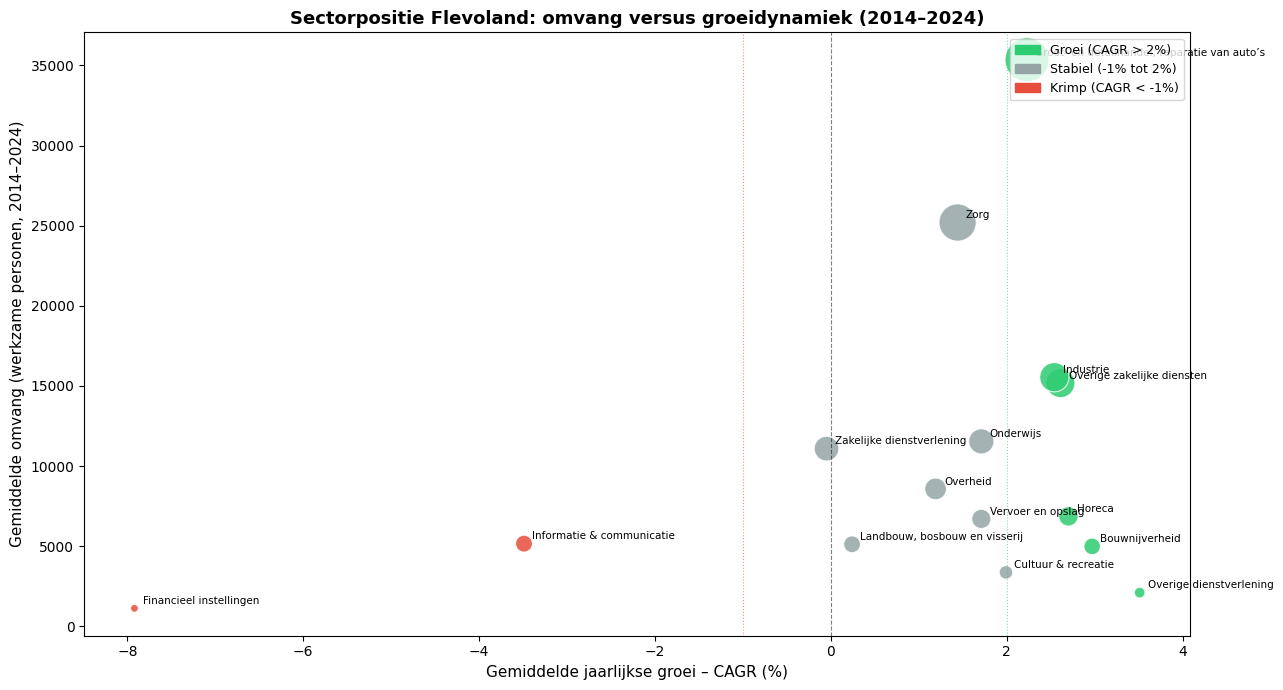

Bron: Provincie Flevoland, Vestigingenregister, peildatum 1 april, 2014–2024.


In [26]:
# Gecombineerde visualisatie: gemiddelde omvang versus CAGR per sector
summary = df_dv2_summary.copy()

# Detecteer kolomnamen ongeacht exacte naam
cagr_col = [c for c in summary.columns if "CAGR" in str(c) or "cagr" in str(c).lower()]
wp14_col = [c for c in summary.columns if "2014" in str(c)]
wp24_col = [c for c in summary.columns if "2024" in str(c)]

if cagr_col and wp14_col and wp24_col:
    cagr_col = cagr_col[0]
    wp14_col = wp14_col[0]
    wp24_col = wp24_col[0]

    summary["gem_omvang"] = (summary[wp14_col] + summary[wp24_col]) / 2

    def kleur(cagr):
        if cagr > 2:    return "#2ecc71"
        elif cagr < -1: return "#e74c3c"
        else:           return "#95a5a6"

    summary["kleur"] = summary[cagr_col].apply(kleur)

    fig, ax = plt.subplots(figsize=(13, 7))
    ax.scatter(
        summary[cagr_col], summary["gem_omvang"],
        s=summary["gem_omvang"] / 35,
        c=summary["kleur"], alpha=0.85,
        edgecolors="white", linewidths=0.8
    )
    for sector, row in summary.iterrows():
        ax.annotate(str(sector), (row[cagr_col], row["gem_omvang"]),
                    fontsize=7.5, xytext=(6, 3), textcoords="offset points")

    ax.axvline(x=0,  color="black",   linestyle="--", linewidth=0.8, alpha=0.5)
    ax.axvline(x=2,  color="#2ecc71", linestyle=":",  linewidth=0.8, alpha=0.6)
    ax.axvline(x=-1, color="#e74c3c", linestyle=":",  linewidth=0.8, alpha=0.6)

    patches = [
        mpatches.Patch(color="#2ecc71", label="Groei (CAGR > 2%)"),
        mpatches.Patch(color="#95a5a6", label="Stabiel (-1% tot 2%)"),
        mpatches.Patch(color="#e74c3c", label="Krimp (CAGR < -1%)")
    ]
    ax.legend(handles=patches, loc="upper right", fontsize=9)
    ax.set_xlabel("Gemiddelde jaarlijkse groei – CAGR (%)", fontsize=11)
    ax.set_ylabel("Gemiddelde omvang (werkzame personen, 2014–2024)", fontsize=11)
    ax.set_title(
        "Sectorpositie Flevoland: omvang versus groeidynamiek (2014–2024)",
        fontsize=13, weight="bold"
    )
    plt.tight_layout()
    plt.show()
    print("Bron: Provincie Flevoland, Vestigingenregister, peildatum 1 april, 2014–2024.")
else:
    print("[INFO] Kolomnamen niet herkend. Controleer de kolomnamen van df_dv2_summary:")
    print(list(summary.columns))

**Interpretatie** 

Op basis van de combinatie van omvang en dynamiek kunnen vier kwalitatief verschillende groepen sectoren worden onderscheiden:

**Groep 1 – Groot en groeiend (hoge beleidsrelevantie)**
Groot- en detailhandel, Industrie en Overige zakelijke diensten zijn zowel groot in absolute omvang als structureel groeiend (CAGR > 2%). Beleid gericht op deze sectoren heeft de grootste absolute impact op de regionale arbeidsmarkt.

**Groep 2 – Groot en stabiel (behoudend beleid)**
Zorg en Zakelijke dienstverlening zijn groot van omvang maar groeien beperkt. Zij vertegenwoordigen een significante basis van de regionale werkgelegenheid. Zonder gerichte groeiimpuls zullen zij relatief in belang afnemen ten opzichte van de groeisectoren.

**Groep 3 – Klein en groeiend (strategisch interessant)**
Bouwnijverheid, Horeca en Overige dienstverlening zijn kleiner in absolute omvang maar laten structurele groei zien. Inhoudelijk interessant, maar hun absolute bijdrage aan de totale werkgelegenheid blijft beperkt.

**Groep 4 – Krimpend (risicosignalering)**
Financiële instellingen en Informatie & communicatie laten een negatieve CAGR zien. Voor de Provincie Flevoland is het relevant te begrijpen of deze krimp sectorspecifiek is of veroorzaakt wordt door regionale factoren die beleidsmatig beïnvloedbaar zijn.

### 9. Koppeling aan de businessvraag

De businessvraag van de Provincie Flevoland luidt: "Hoe zal de werkgelegenheid per sector in Flevoland zich ontwikkelen in de komende 10 jaar?"

Op basis van de gecombineerde analyse van Mohammed en Ismael kunnen de volgende inhoudelijke conclusies worden getrokken als voorbereiding op de beantwoording van deze vraag:

De totale werkgelegenheid in Flevoland groeit structureel. Over de periode 2014–2024 is het aantal werkzame personen toegenomen van 146.751 naar 172.597, een groei van bijna 18%. Er zijn geen aanwijzingen dat deze algemene trend zal omslaan, hoewel externe factoren altijd een onzekerheidsmarge introduceren.

De groei wordt gedomineerd door een beperkt aantal grote sectoren. Groot- en detailhandel, Zorg, Industrie en Overige zakelijke diensten zijn zowel groot in omvang als in absolute groei. Voor een betrouwbare prognose van de totale werkgelegenheid zijn dit de meest relevante sectoren.

Twee sectoren verdienen bijzondere aandacht vanwege krimp. Financiële instellingen laten een structurele en consistente daling zien. Informatie & communicatie laat een deels structurele, deels eenmalige daling zien. Voor beleidsmakers is het relevant te begrijpen of deze krimp compenseerbaar is via groei in andere sectoren.

Beleidskeuzes rond infrastructuur, onderwijs en arbeidsmarkt zullen het meeste effect hebben wanneer zij aansluiten op de groeisectoren met de grootste absolute omvang: handel, zakelijke dienstverlening en industrie.

### 10. Sectorselectie voor fase 4 – Overdracht naar team 2

Op basis van de kwaliteitscontroles en de inhoudelijke analyse wordt de volgende sectorselectie geadviseerd voor voorspellende modellering in fase 4.

De selectie is gebaseerd op drie criteria:

1. Absolute omvang: minimaal 1.000 werkzame personen in 2014.
2. Tijdreekscontinuïteit: aanwezig in alle 11 jaren (2014–2024) zonder gaten.
3. Beleidsrelevantie: aansluiting op de businessvraag van de Provincie Flevoland.

**Categorie A – Primair geschikt voor voorspelling**

* G: Groot- en detailhandel (grootste sector, structurele groei)
* Q: Zorg (tweede grootste sector, stabiele groei)
* N: Overige zakelijke diensten (groot en groeiend)
* C: Industrie (groot en groeiend)
* P: Onderwijs (groot en stabiel)
* F: Bouwnijverheid (middelgroot, sterke groei)
* I: Horeca (middelgroot, sterke groei)

**Categorie B – Bruikbaar, met voorzichtigheid te interpreteren**

* J: Informatie & communicatie (structuurbreuk rond 2017, deels eenmalig)
* K: Financiële instellingen (structurele krimp, kleine omvang einde periode)
* M: Zakelijke dienstverlening (nagenoeg stabiel, minimale trend om te modelleren)

**Categorie C – Buiten scope primaire modellering**

* D: Energie, L: Vastgoed, E: Water & afval, B: Delfstoffen (te kleine absolute omvang)

***Aanbeveling aan team 2:*** 
Begin de modellering met categorie A. Voeg categorie B toe als aanvullende analyse, maar communiceer de beperkingen ervan expliciet in de eindpresentatie. Categorie C kan als aanvullende context worden vermeld, maar is niet geschikt als basis voor een 10-jaars prognose.

### 11. Beperkingen van de analyse

**Beperking 1 – CAGR en relatieve groei bij kleine sectoren**

De CAGR drukt gemiddelde jaarlijkse groei uit als percentage. Bij sectoren met een kleine absolute omvang in 2014 kan een kleine absolute verandering tot een hoog procentueel effect leiden. De drempel van 1.000 werkzame personen is gehanteerd om dit effect te beperken.

**Beperking 2 – Definitie van werkzame personen**

De variabele wp telt het aantal werkzame personen per vestiging, inclusief deeltijdwerkers en zzp'ers. Er wordt geen onderscheid gemaakt naar arbeidsduur of type dienstverband. Een toename van het aantal werkzame personen impliceert daardoor niet automatisch een gelijkwaardige toename in voltijdequivalenten. Dit is met name relevant bij sectoren met een hoog aandeel deeltijdwerk, zoals de zorg.

**Beperking 3 – Historische data als basis voor prognose**

De analyse is gebaseerd op historische ontwikkelingen. Externe factoren zoals beleidswijzigingen, nationale economische schokken, technologische ontwikkelingen en demografische veranderingen zijn niet expliciet in de historische tijdreeks verwerkt. Een prognose op basis van deze data heeft daardoor een inherente onzekerheidsmarge die in de eindpresentatie duidelijk gecommuniceerd moet worden.

**Beperking 4 – Eenmalige effecten versus structurele trends**

De sterke daling in de sector Informatie & communicatie rond 2016–2017 is mogelijk deels veroorzaakt door een eenmalige verandering in registratie of bedrijfsstructuur. Dit maakt de voorspelling voor deze sector onzekerder dan voor sectoren met een consistente lineaire trend.

### 12. Vervolgstappen voor team 2

1. Gebruik de gecontroleerde tijdreeksstructuur als input. Het bestand deelvraag1_sector_trend.csv heeft een correcte structuur en is vrij van missende waarden en duplicaten.

2. Selecteer de sectoren uit categorie A als primaire modelleringsbasis. Dit zijn G, Q, N, C, P, F en I.

3. Kies per sector een passend voorspelmodel. Voor sectoren met een duidelijke lineaire trend is lineaire regressie een verdedigbare keuze. Voor sectoren met niet-lineaire patronen kan tijdreeksanalyse (bijv. ARIMA) geschikter zijn. Valideer het modeltype aan de hand van de residuenplot.

4. Valideer elk model op historische data vóór de definitieve voorspelling. Gebruik bij voorkeur een train/test-splitsing (bijv. 2014–2021 als trainset, 2022–2024 als testset) om de voorspelkracht te beoordelen voordat voorspellingen voor de komende tien jaar worden gegenereerd.

5. Communiceer onzekerheid expliciet in de eindpresentatie. Vermeld per sectorprognose welk model is gebruikt, wat de modelkwaliteit is (bijv. MAPE of R²) en welke factoren buiten het model vallen.

6. Koppel de voorspellingen terug aan de businessvraag. De eindconclusie voor de Provincie Flevoland moet niet alleen bestaan uit cijfers, maar ook uit een beleidsadvies: welke sectoren verdienen investering, welke verdienen aandacht vanwege krimp, en wat betekent dit voor infrastructuur, onderwijs en arbeidsmarktbeleid in Flevoland.

### 13. Conclusie

De resultaten van Mohammed en Ismael zijn inhoudelijk consistent en vullen elkaar aan. De kwaliteitscontroles op volledigheid, uniciteit, tijdreeksstructuur en sectorale consistentie tonen aan dat de aangeleverde outputbestanden bruikbaar zijn als basis voor fase 4. Er zijn geen datakwaliteitsproblemen aangetroffen die correctie vereisen vóór overdracht.

De gecombineerde analyse laat zien dat de totale werkgelegenheid in Flevoland over de periode 2014–2024 structureel is gegroeid, aangedreven door een beperkt aantal grote sectoren. Groot- en detailhandel is veruit de grootste sector, gevolgd door Zorg, Industrie en Overige zakelijke diensten. Zes sectoren laten een gemiddelde jaarlijkse groei van meer dan 2% zien; twee sectoren — Financiële instellingen en Informatie & communicatie — laten een negatieve CAGR zien.

Voor de Provincie Flevoland zijn de groeisectoren met grote absolute omvang het meest relevant voor de businessvraag: zij zijn bepalend voor de toekomstige werkgelegenheidsontwikkeling in de regio. Een prognose gebaseerd op de sectoren uit categorie A biedt een betrouwbare en beleidsrelevante basis voor de 10-jaars voorspelling.

Het werk van team 1 is daarmee niet alleen samengevat, maar ook gecontroleerd op datakwaliteit, inhoudelijk geïnterpreteerd in combinatie met de businessvraag, en overgedragen aan team 2 met een concrete en onderbouwde sectorselectie.